In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
df_train = pd.read_csv('/kaggle/input/original-depresive/train_df_depressive.csv')
df_test = pd.read_csv('/kaggle/input/original-depresive/test_df_depressive.csv')

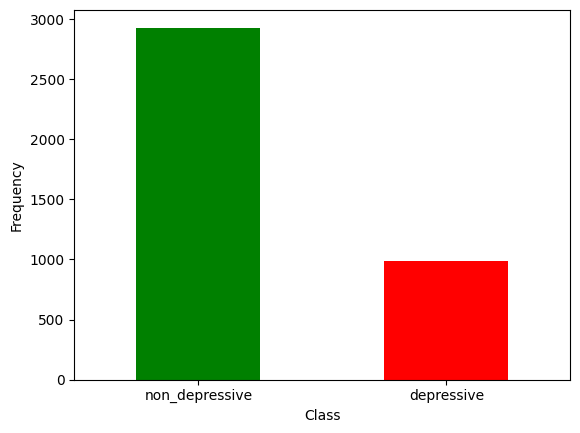

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
df_train = pd.read_csv('/kaggle/input/original-depresive/train_df_depressive.csv')
df_test = pd.read_csv('/kaggle/input/original-depresive/test_df_depressive.csv')

# Merge the datasets
df = pd.concat([df_train, df_test])

# Create the class distribution bar chart
class_counts = df['label'].value_counts()
class_counts.plot(kind='bar', color=['green', 'red'])

plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
# plt.show()

# Save the figure with high DPI
plt.savefig('class_distribution.png', dpi=300)

# Show the plot
plt.show()


In [ ]:
from sklearn.utils import resample

# Separate the majority and minority classes
df_majority = df_train[df_train.label == "non_depressive"]
df_minority = df_train[df_train.label == "depressive"]

# Perform random oversampling on the minority class
df_minority_oversampled = resample(df_minority,
                                   replace=True,  # sample with replacement
                                   n_samples=len(df_majority),  # to match majority class
                                   random_state=42)  # for reproducibility

# Combine majority class with oversampled minority class
df_oversampled = pd.concat([df_majority, df_minority_oversampled])

# Shuffle the DataFrame to mix the oversampled minority class with the majority class
df_oversampled = df_oversampled.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the new DataFrame
print(df_oversampled)

In [ ]:
df_train = df_oversampled

In [ ]:
df_train.label.value_counts()

In [ ]:
print("Information of TrainSet dataframe....")
df_train.info()

In [ ]:
print("Information of TrainSet dataframe....")
df_test.info()

In [ ]:
import re

def text_to_word_list(text):
    text = text.split()
    return text

def replace_strings(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           u"\u00C0-\u017F"          #latin
                           u"\u2000-\u206F"          #generalPunctuations
                               
                           "]+", flags=re.UNICODE)
    english_pattern=re.compile('[a-zA-Z0-9]+', flags=re.I)
    #latin_pattern=re.compile('[A-Za-z\u00C0-\u00D6\u00D8-\u00f6\u00f8-\u00ff\s]*',)
    
    text=emoji_pattern.sub(r'', text)
    text=english_pattern.sub(r'', text)

    return text

def remove_punctuations(my_str):
    # define punctuation
    punctuations = '''````£|¢|Ñ+-*/=EROero৳০১২৩৪৫৬৭৮৯012–34567•89।!()-[]{};:'"“\’,<>./?@#$%^&*_~‘—॥”‰🤣⚽️✌�￰৷￰'''
    
    no_punct = ""
    for char in my_str:
        if char not in punctuations:
            no_punct = no_punct + char

    # display the unpunctuated string
    return no_punct



def joining(text):
    out=' '.join(text)
    return out

def preprocessing(text):
    out=remove_punctuations(replace_strings(text))
    return out

In [ ]:
df_train['text'] = df_train.text.apply(lambda x: preprocessing(str(x)))
df_test['text'] = df_test.text.apply(lambda x: preprocessing(str(x)))

In [ ]:
df_train['text'].iloc[0]

In [ ]:
data1 =pd.read_excel('/kaggle/input/bangla-stopwords/stopwords_bangla.xlsx')
stop = data1['words'].tolist()

In [ ]:
display(data1)

In [ ]:
def stopwordRemoval(text):    
    x=str(text)
    l=x.split()

    stm=[elem for elem in l if elem not in stop]
    
    out=' '.join(stm)
    
    return str(out)

# df_train['text'] = df_train.text.apply(lambda x: stopwordRemoval(str(x)))
# df_test['text'] = df_test.text.apply(lambda x: stopwordRemoval(str(x)))

In [ ]:
df_train.text.iloc[0]

In [ ]:
df_test.text.iloc[0]

In [ ]:
for i in range(20):
    print(df_train.text.iloc[i])

In [ ]:
df_train['text'] = df_train['text'].str.replace(r'\s+', ' ', regex=True).str.strip()
df_test['text'] = df_test['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [ ]:
for i in range(20):
    print(df_train.text.iloc[i])

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical


# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # Limit the number of features for efficiency

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['text']).toarray()

# Transform the testing data
X_test_tfidf = tfidf_vectorizer.transform(df_test['text']).toarray()

# Encode labels
le = LabelEncoder()
y_train = le.fit_transform(df_train['label'])
y_test = le.transform(df_test['label'])

# One-hot encode the labels
y_train = to_categorical(y_train, num_classes=2)
y_test = to_categorical(y_test, num_classes=2)


In [ ]:
# Reshape the data to fit the model
X_train_cnn = X_train_tfidf.reshape((X_train_tfidf.shape[0], X_train_tfidf.shape[1], 1))
X_test_cnn = X_test_tfidf.reshape((X_test_tfidf.shape[0], X_test_tfidf.shape[1], 1))


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Bidirectional, LSTM, BatchNormalization
from tensorflow import keras

# Define the CNN + BiLSTM model
model = Sequential([
    Conv1D(100, 3, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(128, return_sequences=True)),
    BatchNormalization(),
    Flatten(),
    Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.1)),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks for early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)

# Train the model with callbacks
history = model.fit(X_train_cnn, y_train, epochs=60, batch_size=16, validation_split=0.2,
                    callbacks=[early_stopping, reduce_lr])


In [ ]:
loss, accuracy = model.evaluate(X_test_cnn, y_test)
print(f'Accuracy: {accuracy * 100:.2f}%')


In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Predict the labels for the test set
y_pred = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate classification report
report = classification_report(y_true, y_pred_classes, target_names=le.classes_)
print(report)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

# Only for the positive class (assuming binary classification)
fpr[1], tpr[1], _ = roc_curve(y_true, y_pred[:, 1])
roc_auc[1] = auc(fpr[1], tpr[1])

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr[1], tpr[1], color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc[1])
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
